# Fine-tune SciBERT on PubMed 20k RTC
Classifies sentences into: BACKGROUND, OBJECTIVE, METHOD, RESULT, CONCLUSION

In [10]:
!pip install transformers datasets scikit-learn -q

In [11]:
from google.colab import drive
import zipfile

drive.mount("/content/drive")

zip_path = "/content/drive/MyDrive/Human-AI Class Project/archive.zip"
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(".")
!ls

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
drive
PubMed_200k_RCT
PubMed_200k_RCT_numbers_replaced_with_at_sign
PubMed_20k_RCT
PubMed_20k_RCT_numbers_replaced_with_at_sign
sample_data


In [16]:
import pandas as pd

DATA_DIR = "/content/PubMed_20k_RCT"

train_raw = pd.read_csv(f"{DATA_DIR}/train.csv")
val_raw   = pd.read_csv(f"{DATA_DIR}/dev.csv")
test_raw  = pd.read_csv(f"{DATA_DIR}/test.csv")

print(train_raw.head())
print("Columns:", train_raw.columns.tolist())
print(f"Train: {len(train_raw)}  Val: {len(val_raw)}  Test: {len(test_raw)}")

   abstract_id        line_id  \
0     24293578  24293578_0_12   
1     24293578  24293578_1_12   
2     24293578  24293578_2_12   
3     24293578  24293578_3_12   
4     24293578  24293578_4_12   

                                       abstract_text  line_number  \
0  To investigate the efficacy of 6 weeks of dail...            0   
1  A total of 125 patients with primary knee OA w...            1   
2  Outcome measures included pain reduction and i...            2   
3  Pain was assessed using the visual analog pain...            3   
4  Secondary outcome measures included the Wester...            4   

   total_lines     target  
0           12  OBJECTIVE  
1           12    METHODS  
2           12    METHODS  
3           12    METHODS  
4           12    METHODS  
Columns: ['abstract_id', 'line_id', 'abstract_text', 'line_number', 'total_lines', 'target']
Train: 180040  Val: 30212  Test: 30135


In [18]:
# --- Adjust these column names if needed after seeing the output above ---
TEXT_COL  = "abstract_text"
LABEL_COL = "target"

def prepare(df):
    df = df[[TEXT_COL, LABEL_COL]].dropna().copy()
    df.columns = ["text", "label"]
    return df

train_df = prepare(train_raw)
val_df   = prepare(val_raw)
test_df  = prepare(test_raw)

# Encode string labels to integers
label_names = sorted(train_df["label"].unique().tolist())
label2id = {l: i for i, l in enumerate(label_names)}
id2label = {i: l for l, i in label2id.items()}

for df in [train_df, val_df, test_df]:
    df["label_id"] = df["label"].map(label2id)

print("Labels:", label_names)
print(train_df["label"].value_counts())

Labels: ['BACKGROUND', 'CONCLUSIONS', 'METHODS', 'OBJECTIVE', 'RESULTS']
label
METHODS        59353
RESULTS        57953
CONCLUSIONS    27168
BACKGROUND     21727
OBJECTIVE      13839
Name: count, dtype: int64


In [19]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.1, random_state=42, stratify=df["label_id"])
train_df, val_df = train_test_split(train_df, test_size=0.1, random_state=42, stratify=train_df["label_id"])

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

Train: 24408  Val: 2713  Test: 3014


In [20]:
from transformers import AutoTokenizer
from datasets import Dataset

MODEL_NAME = "allenai/scibert_scivocab_uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=128)

train_ds = Dataset.from_pandas(train_df[["text", "label_id"]].rename(columns={"label_id": "labels"}))
val_ds   = Dataset.from_pandas(val_df[["text", "label_id"]].rename(columns={"label_id": "labels"}))
test_ds  = Dataset.from_pandas(test_df[["text", "label_id"]].rename(columns={"label_id": "labels"}))

train_ds = train_ds.map(tokenize, batched=True)
val_ds   = val_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

train_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
val_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/24408 [00:00<?, ? examples/s]

Map:   0%|          | 0/2713 [00:00<?, ? examples/s]

Map:   0%|          | 0/3014 [00:00<?, ? examples/s]

In [21]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
    }

training_args = TrainingArguments(
    output_dir="scibert-pubmed-rtc",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_steps=100,
    fp16=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

trainer.train()

pytorch_model.bin:   0%|          | 0.00/442M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.431361,0.420642,0.847033,0.789990
2,0.292619,0.411083,0.858828,0.800165
3,0.174127,0.442880,0.863620,0.806722


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=2289, training_loss=0.32742100920204303, metrics={'train_runtime': 476.2661, 'train_samples_per_second': 153.746, 'train_steps_per_second': 4.806, 'total_flos': 4816640715945984.0, 'train_loss': 0.32742100920204303, 'epoch': 3.0})

In [22]:
# --- Evaluation on held-out test set ---
predictions = trainer.predict(test_ds)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

print(classification_report(labels, preds, target_names=label_names))

              precision    recall  f1-score   support

  BACKGROUND       0.71      0.74      0.72       362
 CONCLUSIONS       0.82      0.77      0.80       457
     METHODS       0.92      0.94      0.93       990
   OBJECTIVE       0.70      0.58      0.64       233
     RESULTS       0.89      0.91      0.90       972

    accuracy                           0.86      3014
   macro avg       0.81      0.79      0.80      3014
weighted avg       0.85      0.86      0.85      3014



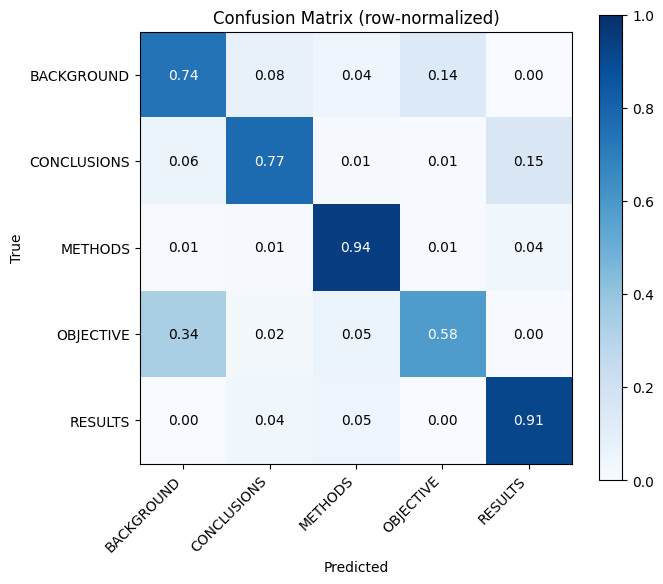

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(labels, preds)
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_normalized, cmap="Blues", vmin=0, vmax=1)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(label_names)))
ax.set_yticks(range(len(label_names)))
ax.set_xticklabels(label_names, rotation=45, ha="right")
ax.set_yticklabels(label_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix (row-normalized)")

for i in range(len(label_names)):
    for j in range(len(label_names)):
        ax.text(j, i, f"{cm_normalized[i, j]:.2f}",
                ha="center", va="center",
                color="white" if cm_normalized[i, j] > 0.5 else "black")

plt.tight_layout()
plt.show()

In [26]:
# --- Save model + tokenizer to Google Drive ---
import json, shutil

SAVE_PATH = "scibert-pubmed-rtc-final"
DRIVE_PATH = "/content/drive/MyDrive/human-ai class project/scibert-pubmed-rtc-final"

trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

with open(f"{SAVE_PATH}/label_map.json", "w") as f:
    json.dump({"id2label": id2label, "label2id": label2id}, f)

shutil.make_archive(DRIVE_PATH, "zip", SAVE_PATH)
print(f"Saved to {DRIVE_PATH}.zip")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to /content/drive/MyDrive/human-ai class project/scibert-pubmed-rtc-final.zip


In [25]:
# --- Save model + tokenizer, then zip for download ---
import json, shutil
from google.colab import files

SAVE_PATH = "scibert-pubmed-rtc-final"
trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

# Save label mapping so classifier.py can load it
with open(f"{SAVE_PATH}/label_map.json", "w") as f:
    json.dump({"id2label": id2label, "label2id": label2id}, f)

shutil.make_archive(SAVE_PATH, "zip", SAVE_PATH)
files.download(f"{SAVE_PATH}.zip")
print("Done — unzip into service/model/ in your project")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 